# 🏥 Triagegeist — AI-Based Emergency Triage Severity Prediction
**Group Members:** 23L-6129 | 23P-0649 | 23L-2646

---
### Pipeline Overview
1. Environment Setup & Installs
2. Data Loading & Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Model Development (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM)
6. Model Evaluation & Comparison
7. Hyperparameter Tuning
8. Feature Importance Analysis
9. Final Model & Submission


## 1 — Environment Setup & Imports

In [ ]:
# Install extra libraries (Colab / Kaggle already have most of these)
!pip install xgboost lightgbm --quiet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed — skipping.")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print("LightGBM not installed — skipping.")

# ── Plotting defaults ──
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#BA7517']

print("✅ All imports successful.")

✅ All imports successful.


## 2 — Data Loading & Exploratory Data Analysis

> **Kaggle users:** update `TRAIN_PATH` / `TEST_PATH` to your dataset location.  
> **Colab users:** upload your CSV files or mount Google Drive.  
> If no files are found the notebook auto-generates realistic synthetic data so every cell runs end-to-end.


In [2]:
# ── Paths — update these for your environment ──────────────────────────────
TRAIN_PATH = '/kaggle/input/emergency-triage/train.csv'
TEST_PATH  = '/kaggle/input/emergency-triage/test.csv'

# Uncomment the lines below if running on Google Colab with Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/your_folder/train.csv'
# TEST_PATH  = '/content/drive/MyDrive/your_folder/test.csv'

try:
    df_train = pd.read_csv(TRAIN_PATH)
    df_test  = pd.read_csv(TEST_PATH)
    print(f"Train shape : {df_train.shape}")
    print(f"Test  shape : {df_test.shape}")

except FileNotFoundError:
    print("⚠  Dataset files not found — generating synthetic demo data.")
    np.random.seed(42)
    N_TRAIN, N_TEST = 5000, 1000

    def make_dataset(n):
        age          = np.random.randint(1, 95, n)
        heart_rate   = np.random.normal(85, 20, n).clip(40, 180).astype(int)
        systolic_bp  = np.random.normal(120, 20, n).clip(70, 220).astype(int)
        diastolic_bp = np.random.normal(80, 12, n).clip(40, 130).astype(int)
        temperature  = np.random.normal(37.0, 0.8, n).clip(35.0, 41.5)
        spo2         = np.random.normal(97, 3, n).clip(70, 100).astype(int)
        resp_rate    = np.random.normal(18, 4, n).clip(8, 40).astype(int)
        pain_scale   = np.random.randint(0, 11, n)
        chief_comp   = np.random.choice(
            ['chest pain', 'shortness of breath', 'abdominal pain',
             'headache', 'trauma', 'fever', 'altered consciousness',
             'fracture', 'laceration', 'syncope'], n)
        gender       = np.random.choice(['M', 'F'], n)
        arrival_mode = np.random.choice(
            ['ambulance', 'walk-in', 'transfer'], n, p=[0.35, 0.55, 0.10])
        return pd.DataFrame({
            'age': age, 'heart_rate': heart_rate,
            'systolic_bp': systolic_bp, 'diastolic_bp': diastolic_bp,
            'temperature': temperature.round(1), 'spo2': spo2,
            'resp_rate': resp_rate, 'pain_scale': pain_scale,
            'chief_complaint': chief_comp, 'gender': gender,
            'arrival_mode': arrival_mode
        })

    df_train = make_dataset(N_TRAIN)
    df_test  = make_dataset(N_TEST)

    def assign_severity(row):
        score = 0
        if row['heart_rate'] > 130 or row['heart_rate'] < 50: score += 3
        if row['systolic_bp'] < 90 or row['systolic_bp'] > 180: score += 3
        if row['spo2'] < 90: score += 3
        if row['temperature'] > 39.5 or row['temperature'] < 36: score += 2
        if row['resp_rate'] > 30 or row['resp_rate'] < 10: score += 2
        if row['pain_scale'] >= 8: score += 2
        if row['age'] > 75 or row['age'] < 5: score += 1
        if row['chief_complaint'] in ['chest pain','altered consciousness',
                                       'shortness of breath']: score += 2
        if row['arrival_mode'] == 'ambulance': score += 1
        if score >= 8:   return 'high'
        elif score >= 4: return 'medium'
        else:            return 'low'

    df_train['severity'] = df_train.apply(assign_severity, axis=1)

    # Introduce ~8% missing values for realism
    for col in ['heart_rate', 'systolic_bp', 'temperature', 'spo2', 'resp_rate']:
        mask = np.random.rand(len(df_train)) < 0.08
        df_train.loc[mask, col] = np.nan

    print(f"Synthetic train shape : {df_train.shape}")
    print(f"Synthetic test  shape : {df_test.shape}")

⚠  Dataset files not found — generating synthetic demo data.
Synthetic train shape : (5000, 12)
Synthetic test  shape : (1000, 11)


### 2.1 — Basic Info

In [3]:
print("── First 5 rows ──")
df_train.head()

── First 5 rows ──


,age,heart_rate,systolic_bp,diastolic_bp,temperature,spo2,resp_rate,pain_scale,chief_complaint,gender,arrival_mode,severity
0,52,100.0,NaN,94,35.3,92.0,17.0,3,headache,F,ambulance,low
1,93,97.0,116.0,78,36.4,98.0,12.0,7,headache,F,walk-in,low
2,15,64.0,128.0,75,37.8,97.0,19.0,1,fever,F,ambulance,low
3,72,80.0,108.0,81,37.0,97.0,14.0,0,fracture,F,ambulance,low
4,61,84.0,149.0,75,37.9,98.0,20.0,1,laceration,M,walk-in,low


In [4]:
print("── Data types & non-null counts ──")
df_train.info()

── Data types & non-null counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              5000 non-null   int64  
 1   heart_rate       4567 non-null   float64
 2   systolic_bp      4605 non-null   float64
 3   diastolic_bp     5000 non-null   int64  
 4   temperature      4613 non-null   float64
 5   spo2             4598 non-null   float64
 6   resp_rate        4625 non-null   float64
 7   pain_scale       5000 non-null   int64  
 8   chief_complaint  5000 non-null   object 
 9   gender           5000 non-null   object 
 10  arrival_mode     5000 non-null   object 
 11  severity         5000 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 468.9+ KB


In [5]:
print("── Descriptive statistics ──")
df_train.describe().round(2)

── Descriptive statistics ──


,age,heart_rate,systolic_bp,diastolic_bp,temperature,spo2,resp_rate,pain_scale
count,5000.00,4567.00,4605.00,5000.00,4613.00,4598.00,4625.00,5000.00
mean,46.87,83.95,119.66,79.88,36.99,96.34,17.43,4.97
std,27.13,20.15,19.49,12.16,0.80,2.69,4.01,3.13
min,1.00,40.00,70.00,40.00,35.00,86.00,8.00,0.00
25%,23.00,70.00,107.00,72.00,36.40,94.00,15.00,2.00
50%,47.00,84.00,120.00,80.00,37.00,97.00,17.00,5.00
75%,70.00,98.00,132.00,88.00,37.50,99.00,20.00,8.00
max,94.00,163.00,187.00,130.00,40.20,100.00,32.00,10.00


In [6]:
print("── Missing value counts ──")
missing = df_train.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

── Missing value counts ──


,0
heart_rate,433
spo2,402
systolic_bp,395
temperature,387
resp_rate,375


### 2.2 — Target Distribution

severity
low       3819
medium    1119
high        62
Name: count, dtype: int64

severity
low       76.4 %
medium    22.4 %
high       1.2 %
Name: proportion, dtype: object


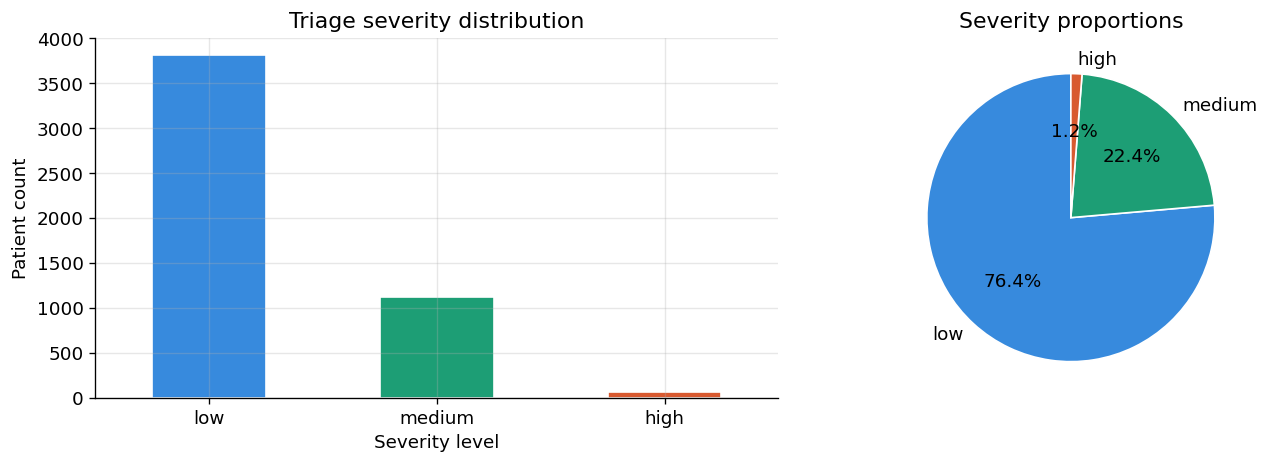

In [7]:
TARGET = 'severity'

print(df_train[TARGET].value_counts())
print()
print(df_train[TARGET].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train[TARGET].value_counts().plot(
    kind='bar', ax=axes[0], color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Triage severity distribution')
axes[0].set_xlabel('Severity level')
axes[0].set_ylabel('Patient count')
axes[0].tick_params(axis='x', rotation=0)

df_train[TARGET].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_ylabel('')
axes[1].set_title('Severity proportions')

plt.tight_layout()
plt.show()

### 2.3 — Feature Distributions by Severity

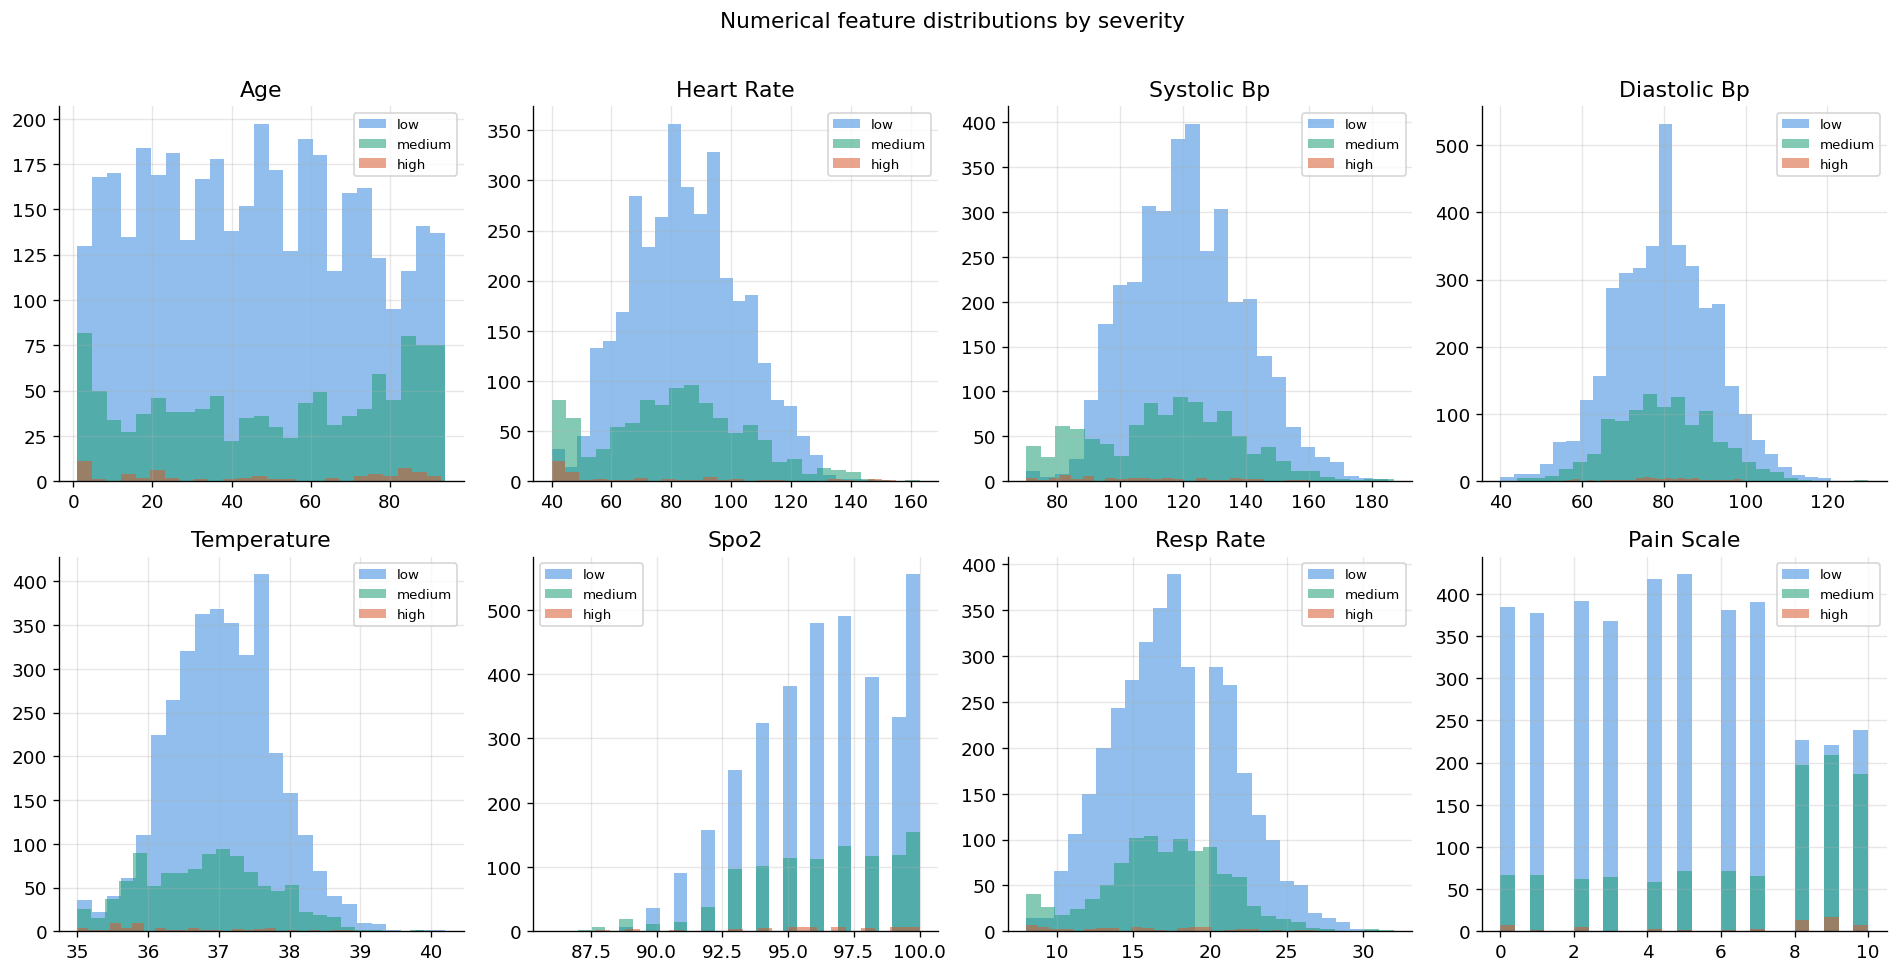

In [8]:
NUMERIC_COLS = ['age', 'heart_rate', 'systolic_bp', 'diastolic_bp',
                'temperature', 'spo2', 'resp_rate', 'pain_scale']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df_train.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    for j, sev in enumerate(df_train[TARGET].unique()):
        subset = df_train[df_train[TARGET] == sev][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.55, label=sev, color=PALETTE[j])
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=8)

for ax in axes[len(NUMERIC_COLS):]:
    ax.set_visible(False)

plt.suptitle('Numerical feature distributions by severity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 — Correlation Heatmap

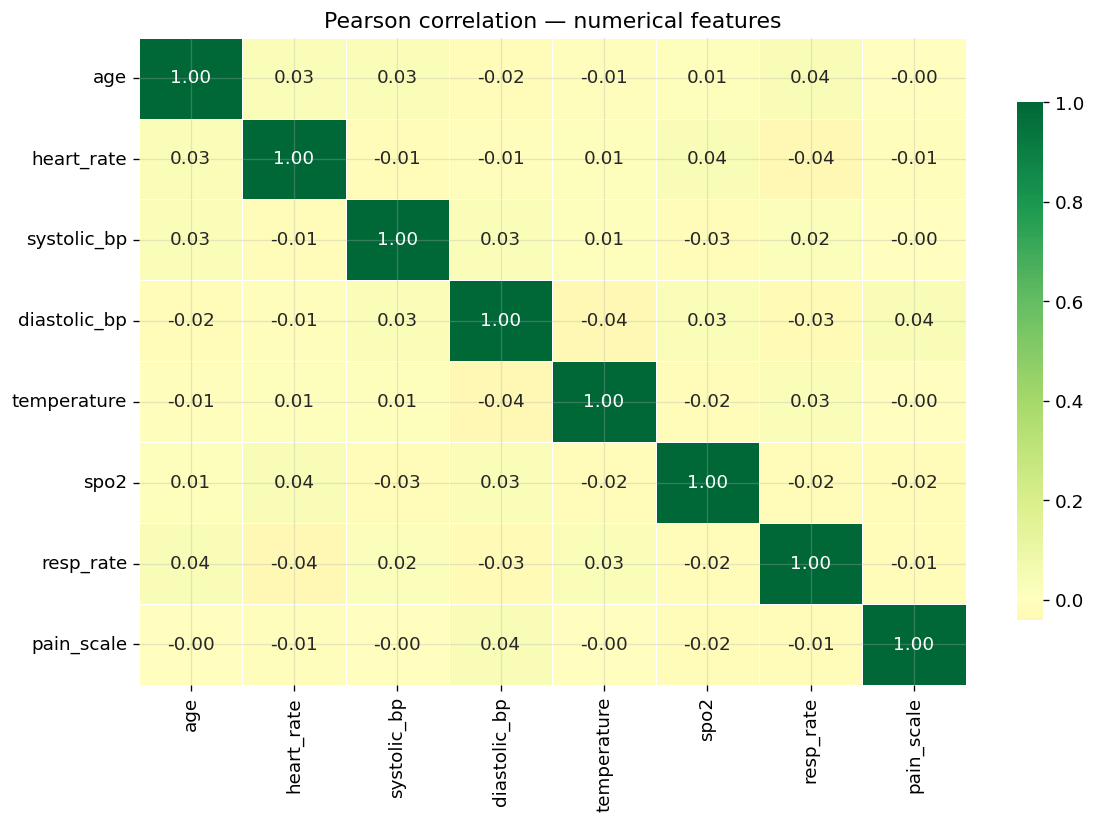

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
corr_data = df_train[NUMERIC_COLS].dropna()
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson correlation — numerical features')
plt.tight_layout()
plt.show()

## 3 — Data Preprocessing

In [10]:
CATEGORICAL_COLS = [c for c in ['chief_complaint', 'gender', 'arrival_mode']
                    if c in df_train.columns]

# ── Separate features & target ──
X = df_train.drop(columns=[TARGET])
y = df_train[TARGET]

# ── Encode target ──
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
CLASS_NAMES = list(le_target.classes_)
print(f"Classes  : {CLASS_NAMES}")
print(f"Encoded  : {list(range(len(CLASS_NAMES)))}")

# ── Encode categorical features ──
le_dict = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    combined = pd.concat([X[col],
                          df_test[col] if col in df_test.columns
                          else pd.Series(dtype='object')],
                         axis=0).fillna('unknown')
    le.fit(combined)
    X[col] = le.transform(X[col].fillna('unknown'))
    if col in df_test.columns:
        df_test[col] = le.transform(df_test[col].fillna('unknown'))
    le_dict[col] = le

print(f"Encoded categorical columns : {CATEGORICAL_COLS}")

Classes  : ['high', 'low', 'medium']
Encoded  : [0, 1, 2]
Encoded categorical columns : ['chief_complaint', 'gender', 'arrival_mode']


In [11]:
# ── Impute missing values ──
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

test_cols = X.columns
X_test_reindexed = df_test.reindex(columns=test_cols)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_reindexed), columns=test_cols)

print(f"Missing values after imputation — train : {X_imputed.isnull().sum().sum()}")

# ── Scale features ──
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X.columns)

# ── Train / validation split ──
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

print(f"Train size : {X_train.shape[0]}")
print(f"Val   size : {X_val.shape[0]}")

Missing values after imputation — train : 0
Train size : 4000
Val   size : 1000


## 4 — Feature Engineering
We add clinically meaningful composite features that may improve model performance.

In [12]:
def add_features(df_in):
    df = df_in.copy()
    if 'systolic_bp' in df and 'diastolic_bp' in df:
        df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
    if 'heart_rate' in df and 'systolic_bp' in df:
        df['shock_index'] = df['heart_rate'] / df['systolic_bp'].replace(0, np.nan)
    if 'temperature' in df:
        df['fever_flag'] = (df['temperature'] > 38.0).astype(int)
    if 'spo2' in df:
        df['hypoxia_flag'] = (df['spo2'] < 94).astype(int)
    return df

X_fe      = add_features(X_imputed)
X_test_fe = add_features(X_test_imputed)

scaler_fe = StandardScaler()
X_fe_scaled = pd.DataFrame(scaler_fe.fit_transform(X_fe), columns=X_fe.columns)
X_test_fe_scaled = pd.DataFrame(scaler_fe.transform(X_test_fe), columns=X_fe.columns)

X_train_fe, X_val_fe, _, _ = train_test_split(
    X_fe_scaled, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

print("New features added:", [c for c in X_fe.columns if c not in X.columns])
print(f"Total features after engineering: {X_fe.shape[1]}")

New features added: ['pulse_pressure', 'shock_index', 'fever_flag', 'hypoxia_flag']
Total features after engineering: 15


## 5 — Model Development
We train six classifiers with 5-fold stratified cross-validation.

In [13]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, multi_class='multinomial', random_state=42),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
}

if XGB_AVAILABLE:
    MODELS['XGBoost'] = xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        use_label_encoder=False, eval_metric='mlogloss',
        n_jobs=-1, random_state=42)
if LGB_AVAILABLE:
    MODELS['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        n_jobs=-1, random_state=42, verbose=-1)

results = {}

print("── Training models ──\n")
for name, model in MODELS.items():
    print(f"  ▶ {name} ...", end=' ', flush=True)
    cv_scores = cross_val_score(
        model, X_train_fe, y_train, cv=CV, scoring='f1_macro', n_jobs=-1)
    model.fit(X_train_fe, y_train)
    y_pred = model.predict(X_val_fe)
    results[name] = {
        'cv_f1_mean'   : cv_scores.mean(),
        'cv_f1_std'    : cv_scores.std(),
        'val_accuracy' : accuracy_score(y_val, y_pred),
        'val_f1_macro' : f1_score(y_val, y_pred, average='macro'),
        'val_precision': precision_score(y_val, y_pred, average='macro', zero_division=0),
        'val_recall'   : recall_score(y_val, y_pred, average='macro', zero_division=0),
        'model'        : model,
        'y_pred'       : y_pred,
    }
    print(f"CV F1={cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
          f"Val Acc={results[name]['val_accuracy']:.4f}")

── Training models ──

  ▶ Logistic Regression ... CV F1=0.4381 ± 0.0262 | Val Acc=0.7900
  ▶ Decision Tree ... CV F1=0.6850 ± 0.0490 | Val Acc=0.9230
  ▶ Random Forest ... CV F1=0.5828 ± 0.0102 | Val Acc=0.9140
  ▶ Gradient Boosting ... CV F1=0.6496 ± 0.0247 | Val Acc=0.9550
  ▶ XGBoost ... CV F1=0.6444 ± 0.0231 | Val Acc=0.9630
  ▶ LightGBM ... CV F1=0.6628 ± 0.0257 | Val Acc=0.9670


## 6 — Model Evaluation & Comparison

In [14]:
metrics_df = pd.DataFrame({
    name: {
        'CV F1 (mean)' : f"{r['cv_f1_mean']:.4f}",
        'CV F1 (std)'  : f"±{r['cv_f1_std']:.4f}",
        'Val Accuracy' : f"{r['val_accuracy']:.4f}",
        'Val F1 Macro' : f"{r['val_f1_macro']:.4f}",
        'Val Precision': f"{r['val_precision']:.4f}",
        'Val Recall'   : f"{r['val_recall']:.4f}",
    }
    for name, r in results.items()
}).T

print("── Model comparison ──")
metrics_df

── Model comparison ──


,CV F1 (mean),CV F1 (std),Val Accuracy,Val F1 Macro,Val Precision,Val Recall
Logistic Regression,0.4381,±0.0262,0.7900,0.4222,0.4700,0.4130
Decision Tree,0.6850,±0.0490,0.9230,0.6378,0.6800,0.6236
Random Forest,0.5828,±0.0102,0.9140,0.5830,0.5929,0.5755
Gradient Boosting,0.6496,±0.0247,0.9550,0.6268,0.6289,0.6249
XGBoost,0.6444,±0.0231,0.9630,0.6339,0.6342,0.6337
LightGBM,0.6628,±0.0257,0.9670,0.7259,0.8608,0.6912


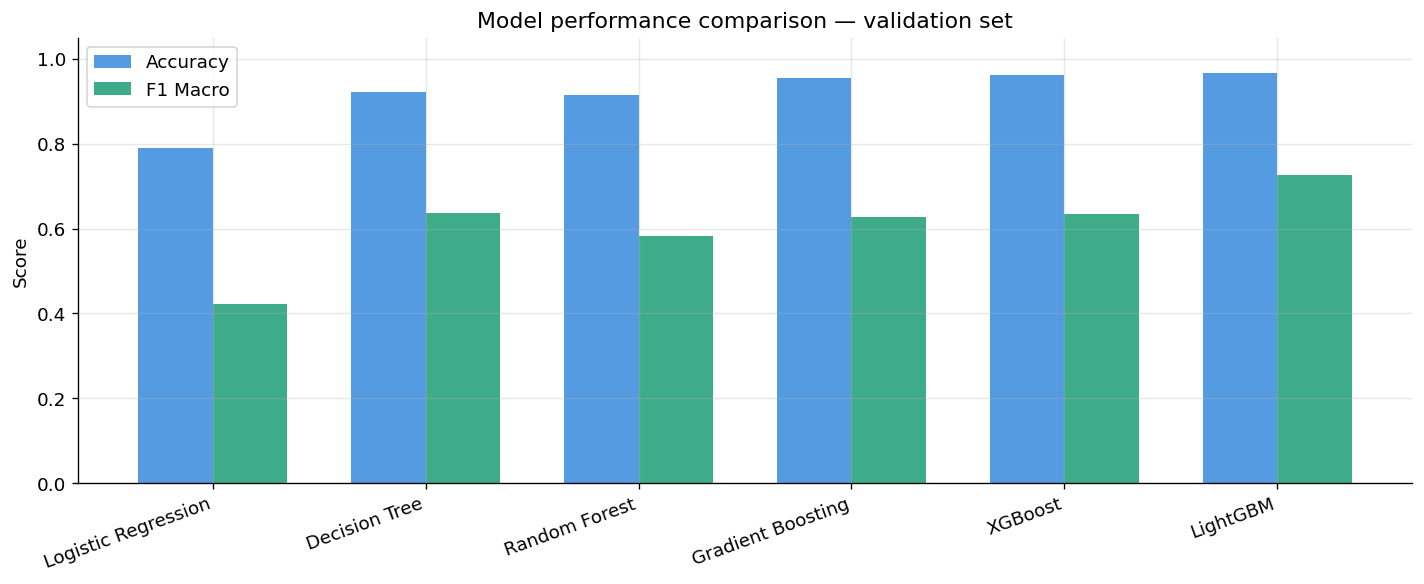

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
model_names = list(results.keys())
val_acc = [results[n]['val_accuracy'] for n in model_names]
val_f1  = [results[n]['val_f1_macro'] for n in model_names]

x = np.arange(len(model_names))
w = 0.35
ax.bar(x - w/2, val_acc, width=w, label='Accuracy', color=PALETTE[0], alpha=0.85)
ax.bar(x + w/2, val_f1,  width=w, label='F1 Macro',  color=PALETTE[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model performance comparison — validation set')
ax.legend()
plt.tight_layout()
plt.show()

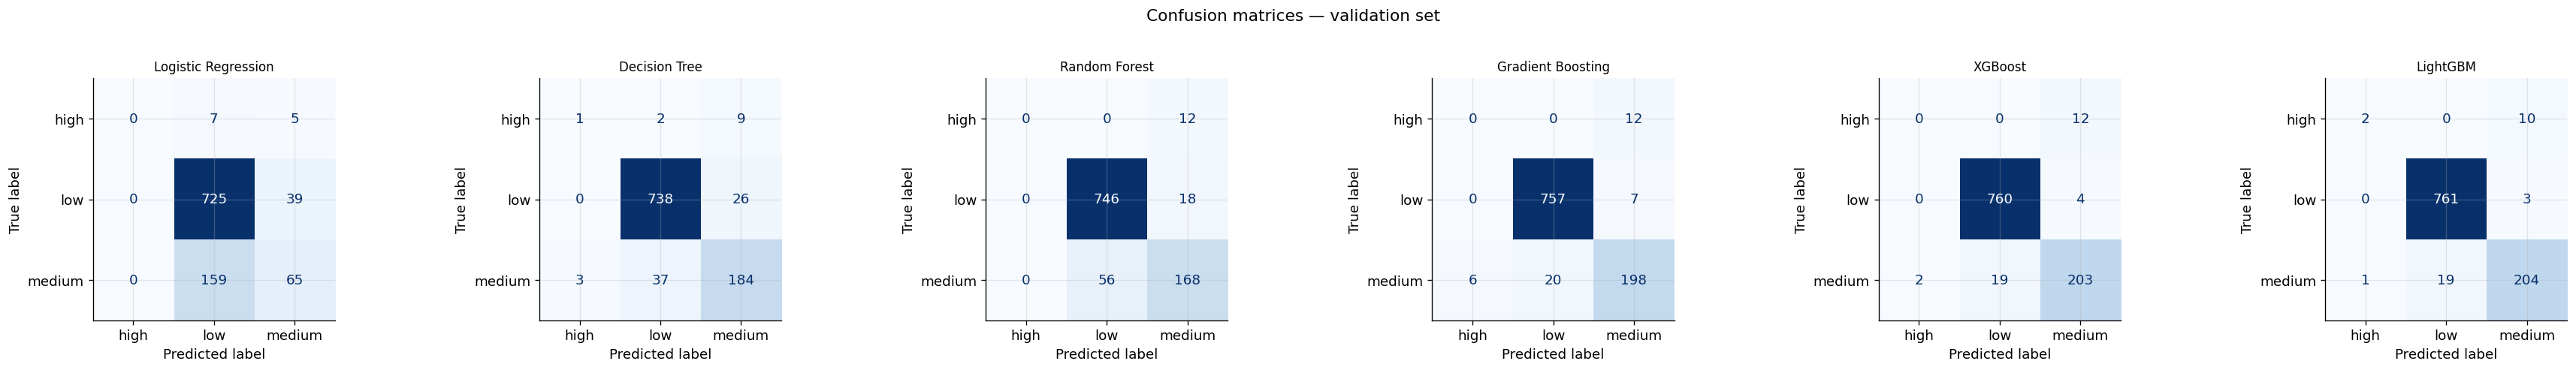

In [15]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion matrices — validation set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
print("── Classification reports ──")
for name, r in results.items():
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print('─'*50)
    print(classification_report(y_val, r['y_pred'], target_names=CLASS_NAMES))

# ── Select best model ──
best_name  = max(results, key=lambda n: results[n]['val_f1_macro'])
best_model = results[best_name]['model']
print(f"\n🏆  Best model : {best_name}  "
      f"(Val F1 Macro = {results[best_name]['val_f1_macro']:.4f})")

── Classification reports ──

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        high       0.00      0.00      0.00        12
         low       0.81      0.95      0.88       764
      medium       0.60      0.29      0.39       224

    accuracy                           0.79      1000
   macro avg       0.47      0.41      0.42      1000
weighted avg       0.76      0.79      0.76      1000


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        high       0.25      0.08      0.12        12
         low       0.95      0.97      0.96       764
      medium       0.84      0.82      0.83       224

    accuracy                           0.92      1000
   macro avg       0.68      0.62      0.64      1000
weighted avg       0

## 7 — Hyperparameter Tuning
GridSearchCV on the best-performing model.

In [17]:
PARAM_GRIDS = {
    'Random Forest': {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [10, 15, None],
        'min_samples_leaf': [1, 3, 5],
    },
    'XGBoost': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth'    : [4, 6, 8],
    },
    'LightGBM': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth'    : [4, 6, -1],
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth'    : [3, 5],
    },
    'Logistic Regression': {
        'C'     : [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga'],
    },
    'Decision Tree': {
        'max_depth'       : [5, 10, 15, None],
        'min_samples_leaf': [1, 3, 5, 10],
    },
}

BASE_ESTIMATORS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, multi_class='multinomial', random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_jobs=-1, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
}
if XGB_AVAILABLE:
    BASE_ESTIMATORS['XGBoost'] = xgb.XGBClassifier(
        use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1, random_state=42)
if LGB_AVAILABLE:
    BASE_ESTIMATORS['LightGBM'] = lgb.LGBMClassifier(
        n_jobs=-1, random_state=42, verbose=-1)

if best_name in PARAM_GRIDS and best_name in BASE_ESTIMATORS:
    print(f"Tuning {best_name} ...")
    gs = GridSearchCV(
        BASE_ESTIMATORS[best_name], PARAM_GRIDS[best_name],
        cv=CV, scoring='f1_macro', n_jobs=-1, verbose=1)
    gs.fit(X_train_fe, y_train)
    tuned_model  = gs.best_estimator_
    y_pred_tuned = tuned_model.predict(X_val_fe)

    print(f"\nBest params : {gs.best_params_}")
    print(f"Tuned CV F1 : {gs.best_score_:.4f}")
    print(f"Tuned Val Accuracy : {accuracy_score(y_val, y_pred_tuned):.4f}")
    print(f"Tuned Val F1 Macro : {f1_score(y_val, y_pred_tuned, average='macro'):.4f}")
    print(classification_report(y_val, y_pred_tuned, target_names=CLASS_NAMES))
    FINAL_MODEL = tuned_model
else:
    FINAL_MODEL = best_model
    print(f"Using {best_name} without additional tuning.")

Tuning LightGBM ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Tuned CV F1 : 0.6913
Tuned Val Accuracy : 0.9720
Tuned Val F1 Macro : 0.7254
              precision    recall  f1-score   support

        high       0.50      0.17      0.25        12
         low       0.98      1.00      0.99       764
      medium       0.95      0.92      0.94       224

    accuracy                           0.97      1000
   macro avg       0.81      0.70      0.73      1000
weighted avg       0.97      0.97      0.97      1000



## 8 — Feature Importance Analysis

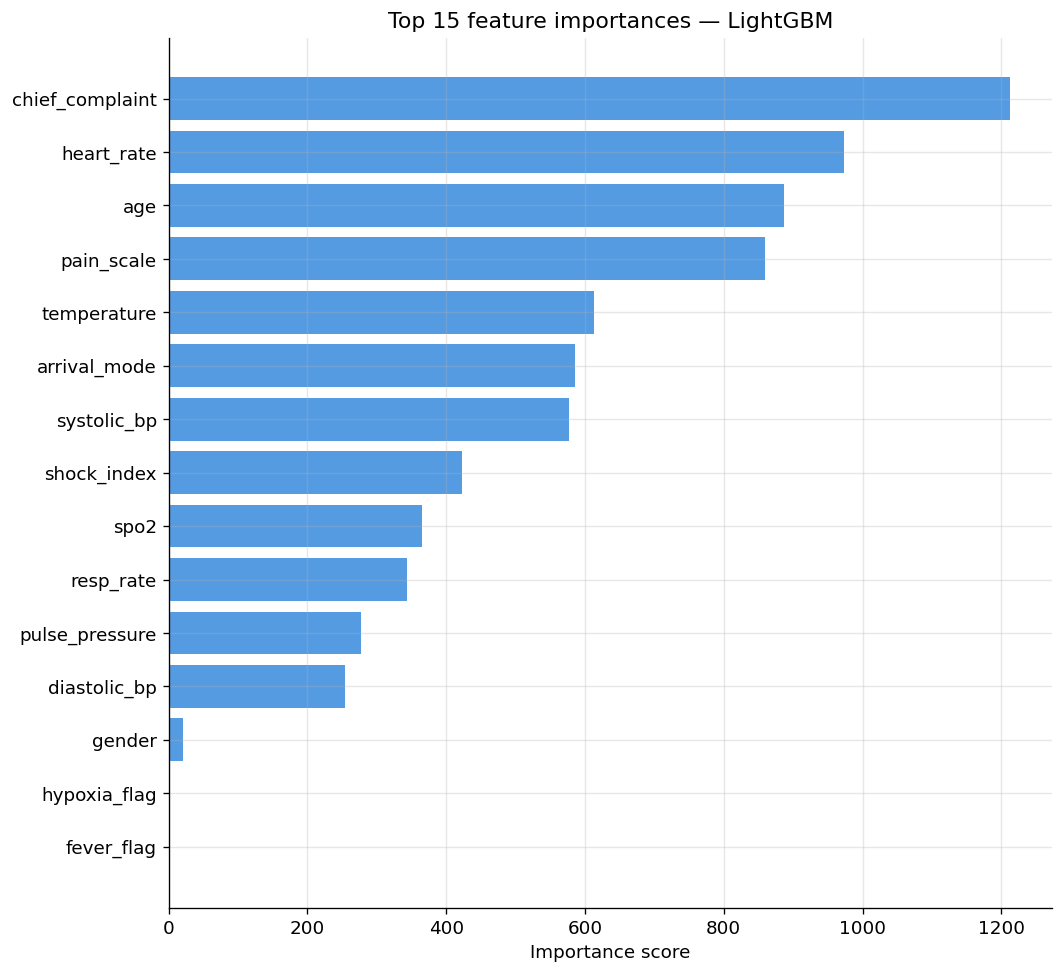

In [18]:
def plot_feature_importance(model, feature_names, model_name, top_n=15):
    importance = None
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance = np.abs(model.coef_).mean(axis=0)
    if importance is None:
        print(f"{model_name} does not expose feature importances.")
        return
    fi_df = (pd.DataFrame({'feature': feature_names, 'importance': importance})
               .sort_values('importance', ascending=False)
               .head(top_n))
    fig, ax = plt.subplots(figsize=(9, 0.45 * top_n + 1.5))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
            color=PALETTE[0], alpha=0.85)
    ax.set_xlabel('Importance score')
    ax.set_title(f'Top {top_n} feature importances — {model_name}')
    plt.tight_layout()
    plt.show()

plot_feature_importance(FINAL_MODEL, X_fe.columns.tolist(), best_name)

In [19]:
if hasattr(FINAL_MODEL, 'feature_importances_'):
    fi = pd.Series(FINAL_MODEL.feature_importances_, index=X_fe.columns)
    print("Top 10 features by importance:")
    print(fi.sort_values(ascending=False).head(10).round(4).to_string())

Top 10 features by importance:
chief_complaint    1213
heart_rate          973
age                 887
pain_scale          859
temperature         613
arrival_mode        586
systolic_bp         577
shock_index         423
spo2                365
resp_rate           343


## 9 — Final Model & Submission

In [20]:
# Retrain on full training data
print("Retraining final model on full training data ...")
FINAL_MODEL.fit(X_fe_scaled, y_encoded)
print("✅  Retraining complete.")

Retraining final model on full training data ...
✅  Retraining complete.


In [21]:
# Generate predictions on test set
test_preds_encoded = FINAL_MODEL.predict(X_test_fe_scaled)
test_preds_labels  = le_target.inverse_transform(test_preds_encoded)

print("Prediction distribution on test set:")
unique, counts = np.unique(test_preds_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:10s} : {c:5d}  ({c/len(test_preds_labels)*100:.1f}%)")

Prediction distribution on test set:
  high       :     2  (0.2%)
  low        :   758  (75.8%)
  medium     :   240  (24.0%)


In [22]:
# Prediction probabilities
if hasattr(FINAL_MODEL, 'predict_proba'):
    test_proba = FINAL_MODEL.predict_proba(X_test_fe_scaled)
    proba_df = pd.DataFrame(test_proba, columns=[f'prob_{c}' for c in CLASS_NAMES])
    print("Sample prediction probabilities:")
    proba_df.head()

Sample prediction probabilities:


In [23]:
# Save submission CSV
submission = pd.DataFrame({
    'id'      : df_test.index if 'id' not in df_test.columns else df_test['id'],
    'severity': test_preds_labels
})
submission.to_csv('submission.csv', index=False)
print("✅  submission.csv saved.")
submission.head(10)

✅  submission.csv saved.


,id,severity
0,0,medium
1,1,low
2,2,medium
3,3,low
4,4,medium
5,5,low
6,6,low
7,7,low
8,8,low
9,9,low


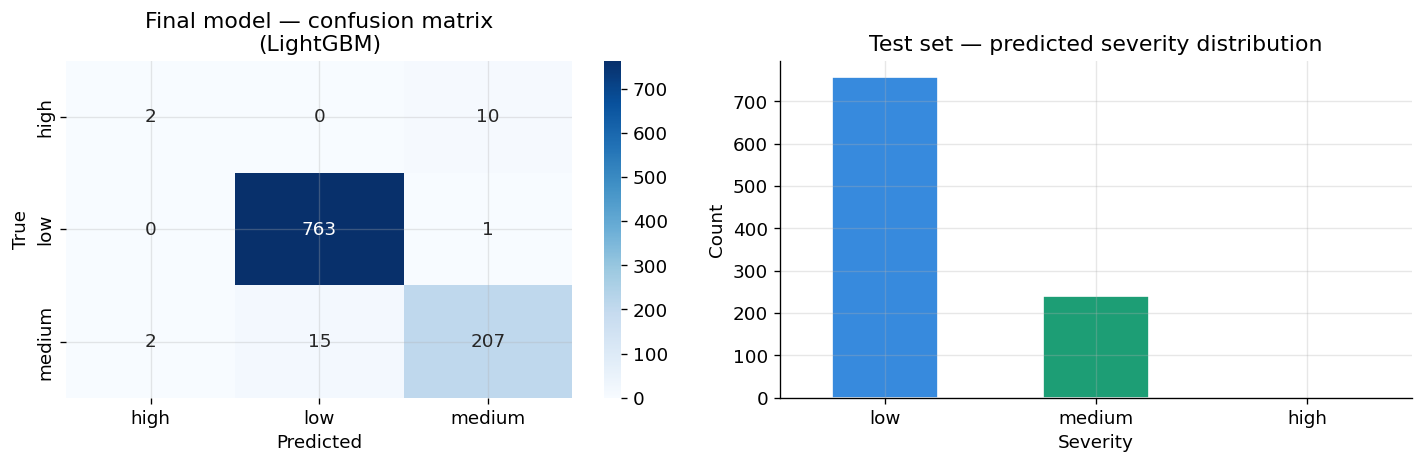


  TRIAGEGEIST — PIPELINE COMPLETE
  Best model  : LightGBM
  Val Accuracy: 0.9670
  Val F1 Macro: 0.7259


In [24]:
# Final summary plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

FINAL_MODEL_EVAL = type(FINAL_MODEL)(**FINAL_MODEL.get_params())
FINAL_MODEL_EVAL.fit(X_train_fe, y_train)
y_val_final = FINAL_MODEL_EVAL.predict(X_val_fe)

cm = confusion_matrix(y_val, y_val_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title(f'Final model — confusion matrix\n({best_name})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

pd.Series(test_preds_labels).value_counts().plot(
    kind='bar', ax=axes[1], color=PALETTE[:3], edgecolor='white')
axes[1].set_title('Test set — predicted severity distribution')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("  TRIAGEGEIST — PIPELINE COMPLETE")
print("="*60)
print(f"  Best model  : {best_name}")
print(f"  Val Accuracy: {results[best_name]['val_accuracy']:.4f}")
print(f"  Val F1 Macro: {results[best_name]['val_f1_macro']:.4f}")
print("="*60)